#  Rapport Final
## Exploration de graphes sociaux : communautés, centralité et structures relationnelles
### Dataset : Facebook Social Circles (SNAP)

Ce notebook présente le projet portant sur l'exploration de graphes sociaux.  
Nous utilisons trois sources principales :

- `facebook_combined.txt.gz` pour l'analyse globale du réseau ;
- `facebook.tar.gz` pour accéder aux ego-networks détaillés ;
- `readme.txt` pour interpréter correctement la structure des fichiers.

L'objectif est de construire un graphe social, d'étudier sa structure, d'analyser les centralités, de détecter des communautés et de comparer certains résultats aux cercles fournis dans les fichiers détaillés.

In [ ]:
import os
import tarfile
import gzip
import warnings
from pathlib import Path

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [ ]:
# Chemins de base
BASE_DIR = Path("../data")
COMBINED_PATH = BASE_DIR / "facebook_combined.txt.gz"
TAR_PATH = BASE_DIR / "facebook.tar.gz"
EXTRACTED_DIR = BASE_DIR / "extracted"

print("Fichier combiné :", COMBINED_PATH)
print("Archive :", TAR_PATH)
print("Dossier extraction :", EXTRACTED_DIR)

Fichier combiné : ..\data\facebook_combined.txt.gz
Archive : ..\data\facebook.tar.gz
Dossier extraction : ..\data\extracted


## Description des fichiers détaillés

D'après la documentation du dataset :

- `nodeId.edges` : arêtes du réseau égocentré du nœud principal ;
- `nodeId.circles` : cercles sociaux associés au nœud principal ;
- `nodeId.feat` : caractéristiques des nœuds présents dans le fichier d'arêtes ;
- `nodeId.egofeat` : caractéristiques de l'utilisateur ego ;
- `nodeId.featnames` : noms des dimensions de caractéristiques.

Dans le cas de Facebook, les arêtes sont non orientées.

In [ ]:
edges_combined = pd.read_csv(
    COMBINED_PATH,
    sep=" ",
    header=None,
    names=["source", "target"],
    compression="gzip"
)

edges_combined.head()

,source,target
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5


In [ ]:
print("Nombre de lignes :", len(edges_combined))
print("\nValeurs nulles :")
print(edges_combined.isnull().sum())

print("\nDoublons :", edges_combined.duplicated().sum())

Nombre de lignes : 88234

Valeurs nulles :
source    0
target    0
dtype: int64

Doublons : 0


In [ ]:
# construire le graphe global
G_combined = nx.from_pandas_edgelist(
    edges_combined,
    source="source",
    target="target"
)

print("Nombre de nœuds :", G_combined.number_of_nodes())
print("Nombre d’arêtes :", G_combined.number_of_edges())

Nombre de nœuds : 4039
Nombre d’arêtes : 88234


In [ ]:
EXTRACTED_DIR.mkdir(parents=True, exist_ok=True)

with tarfile.open(TAR_PATH, "r:gz") as tar:
    tar.extractall(path=EXTRACTED_DIR)

print("Extraction terminée.")

Extraction terminée.


In [ ]:
# lister les fichiers extraits
DATASET_DIR = EXTRACTED_DIR / "facebook"

all_files = sorted([f.name for f in DATASET_DIR.iterdir() if f.is_file()])

print("Nombre total de fichiers extraits :", len(all_files))
print(all_files[:20])

Nombre total de fichiers extraits : 50
['0.circles', '0.edges', '0.egofeat', '0.feat', '0.featnames', '107.circles', '107.edges', '107.egofeat', '107.feat', '107.featnames', '1684.circles', '1684.edges', '1684.egofeat', '1684.feat', '1684.featnames', '1912.circles', '1912.edges', '1912.egofeat', '1912.feat', '1912.featnames']


In [ ]:
# Séparer les types de fichiers
edges_files = sorted([f for f in all_files if f.endswith(".edges")])
circles_files = sorted([f for f in all_files if f.endswith(".circles")])
feat_files = sorted([f for f in all_files if f.endswith(".feat")])
egofeat_files = sorted([f for f in all_files if f.endswith(".egofeat")])
featnames_files = sorted([f for f in all_files if f.endswith(".featnames")])

print("Fichiers .edges :", len(edges_files))
print("Fichiers .circles :", len(circles_files))
print("Fichiers .feat :", len(feat_files))
print("Fichiers .egofeat :", len(egofeat_files))
print("Fichiers .featnames :", len(featnames_files))

Fichiers .edges : 10
Fichiers .circles : 10
Fichiers .feat : 10
Fichiers .egofeat : 10
Fichiers .featnames : 10


.edges = relations entre nœuds
.circles = groupes
.feat = caractéristiques
.egofeat = caractéristiques de l’ego
.featnames = noms des caractéristiques

In [ ]:
print("Exemples de fichiers .edges :")
print(edges_files[:10])

Exemples de fichiers .edges :
['0.edges', '107.edges', '1684.edges', '1912.edges', '3437.edges', '348.edges', '3980.edges', '414.edges', '686.edges', '698.edges']


In [ ]:
# Choisir un ego-network
ego_id = edges_files[0].split(".")[0]
ego_id

'0'

In [ ]:
from pathlib import Path

BASE_DIR = Path("../data")
EXTRACTED_DIR = BASE_DIR / "extracted"

# Détection automatique du bon dossier
if (EXTRACTED_DIR / "facebook").exists():
    DATASET_DIR = EXTRACTED_DIR / "facebook"
else:
    DATASET_DIR = EXTRACTED_DIR

print("Dossier utilisé :", DATASET_DIR.resolve())

all_files = sorted([f.name for f in DATASET_DIR.iterdir() if f.is_file()])
print("Nombre de fichiers détectés :", len(all_files))
print(all_files[:10])

edges_files = sorted([f for f in all_files if f.endswith(".edges")])

ego_id = edges_files[0].split(".")[0]
ego_edges_path = DATASET_DIR / f"{ego_id}.edges"

print("Chemin final :", ego_edges_path)
print("Existe ?", ego_edges_path.exists())

ego_edges = pd.read_csv(
    ego_edges_path,
    sep=" ",
    header=None,
    names=["source", "target"]
)

ego_edges.head()

Dossier utilisé : C:\Users\TRESOR MEGANE\Desktop\projet_IA\data\extracted\facebook
Nombre de fichiers détectés : 50
['0.circles', '0.edges', '0.egofeat', '0.feat', '0.featnames', '107.circles', '107.edges', '107.egofeat', '107.feat', '107.featnames']
Chemin final : ..\data\extracted\facebook\0.edges
Existe ? True


,source,target
0,236,186
1,122,285
2,24,346
3,271,304
4,176,9


In [ ]:
# Construire le graphe ego
G_ego = nx.from_pandas_edgelist(ego_edges, source="source", target="target")

# Ajouter le nœud ego
G_ego.add_node(int(ego_id))

# Connecter l'ego à tous les nœuds présents dans le fichier
for node in set(ego_edges["source"]).union(set(ego_edges["target"])):
    G_ego.add_edge(int(ego_id), node)

print("Ego choisi :", ego_id)
print("Nombre de nœuds dans l'ego-network :", G_ego.number_of_nodes())
print("Nombre d’arêtes dans l'ego-network :", G_ego.number_of_edges())

Ego choisi : 0
Nombre de nœuds dans l'ego-network : 334
Nombre d’arêtes dans l'ego-network : 2852


In [ ]:
# Charger les cercles de cet ego
ego_circles_path = DATASET_DIR / f"{ego_id}.circles"

circles = []

if ego_circles_path.exists():
    with open(ego_circles_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            circle_name = parts[0]
            members = list(map(int, parts[1:]))
            circles.append({"circle": circle_name, "members": members})

print("Nombre de cercles trouvés :", len(circles))
circles[:3]

Nombre de cercles trouvés : 24


[{'circle': 'circle0',
  'members': [71,
   215,
   54,
   61,
   298,
   229,
   81,
   253,
   193,
   97,
   264,
   29,
   132,
   110,
   163,
   259,
   183,
   334,
   245,
   222]},
 {'circle': 'circle1', 'members': [173]},
 {'circle': 'circle2',
  'members': [155, 99, 327, 140, 116, 147, 144, 150, 270]}]

In [ ]:
# Voir la taille des cercles
circles_df = pd.DataFrame({
    "circle": [c["circle"] for c in circles],
    "size": [len(c["members"]) for c in circles]
})

circles_df.sort_values("size", ascending=False).head(10)

,circle,size
15,circle15,133
16,circle16,32
11,circle11,30
0,circle0,20
6,circle6,20
4,circle4,17
19,circle19,13
9,circle9,10
2,circle2,9
17,circle17,9


In [ ]:
# Charger les features du même ego
ego_feat_path = DATASET_DIR/ f"{ego_id}.feat"
ego_egofeat_path = DATASET_DIR / f"{ego_id}.egofeat"
ego_featnames_path = DATASET_DIR / f"{ego_id}.featnames"

In [ ]:
feat_df = pd.read_csv(ego_feat_path, sep=" ", header=None)
feat_df.head()

,0,1,2,3,4,5,6,7,8,9,...,215,216,217,218,219,220,221,222,223,224
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
featnames = []
with open(ego_featnames_path, "r", encoding="utf-8") as f:
    featnames = [line.strip() for line in f]

featnames[:10]

['0 birthday;anonymized feature 0',
 '1 birthday;anonymized feature 1',
 '2 birthday;anonymized feature 2',
 '3 birthday;anonymized feature 3',
 '4 birthday;anonymized feature 4',
 '5 birthday;anonymized feature 5',
 '6 birthday;anonymized feature 6',
 '7 birthday;anonymized feature 7',
 '8 education;classes;id;anonymized feature 8',
 '9 education;classes;id;anonymized feature 9']

In [ ]:
num_nodes = G_combined.number_of_nodes()
num_edges = G_combined.number_of_edges()
density = nx.density(G_combined)
avg_degree = sum(dict(G_combined.degree()).values()) / num_nodes
num_components = nx.number_connected_components(G_combined)
largest_cc = max(nx.connected_components(G_combined), key=len)
largest_cc_size = len(largest_cc)
clustering = nx.average_clustering(G_combined)

print(f"Nombre de nœuds : {num_nodes}")
print(f"Nombre d’arêtes : {num_edges}")
print(f"Densité : {density:.6f}")
print(f"Degré moyen : {avg_degree:.4f}")
print(f"Nombre de composantes connexes : {num_components}")
print(f"Taille de la plus grande composante : {largest_cc_size}")
print(f"Coefficient de clustering moyen : {clustering:.4f}")

Nombre de nœuds : 4039
Nombre d’arêtes : 88234
Densité : 0.010820
Degré moyen : 43.6910
Nombre de composantes connexes : 1
Taille de la plus grande composante : 4039
Coefficient de clustering moyen : 0.6055


In [ ]:
# centralités
import time

start_time = time.time()

degree_centrality = nx.degree_centrality(G_combined)
closeness_centrality = nx.closeness_centrality(G_combined)
betweenness_centrality = nx.betweenness_centrality(G_combined)

end_time = time.time()
print(f"Temps de calcul : {end_time - start_time:.2f} secondes")

Temps de calcul : 885.18 secondes


In [ ]:
def top_k(dictionary, k=10):
    return sorted(dictionary.items(), key=lambda x: x[1], reverse=True)[:k]

top_degree = top_k(degree_centrality)
top_closeness = top_k(closeness_centrality)
top_betweenness = top_k(betweenness_centrality)

print("Top 10 - Degree Centrality")
print(top_degree)

print("\nTop 10 - Closeness Centrality")
print(top_closeness)

print("\nTop 10 - Betweenness Centrality")
print(top_betweenness)

Top 10 - Degree Centrality
[(107, 0.258791480931154), (1684, 0.1961367013372957), (1912, 0.18697374938088163), (3437, 0.13546310054482416), (0, 0.08593363051015354), (2543, 0.07280832095096582), (2347, 0.07206537890044576), (1888, 0.0629024269440317), (1800, 0.06067360079247152), (1663, 0.058197127290737984)]

Top 10 - Closeness Centrality
[(107, 0.45969945355191255), (58, 0.3974018305284913), (428, 0.3948371956585509), (563, 0.3939127889961955), (1684, 0.39360561458231796), (171, 0.37049270575282134), (348, 0.36991572004397216), (483, 0.3698479575013739), (414, 0.3695433330282786), (376, 0.36655773420479304)]

Top 10 - Betweenness Centrality
[(107, 0.4805180785560152), (1684, 0.3377974497301992), (3437, 0.23611535735892905), (1912, 0.2292953395868782), (1085, 0.14901509211665306), (0, 0.14630592147442917), (698, 0.11533045020560802), (567, 0.09631033121856215), (58, 0.08436020590796486), (428, 0.06430906239323866)]


In [ ]:
# creer des tableaux propres
import pandas as pd

top_degree_df = pd.DataFrame(top_degree, columns=["node", "degree_centrality"])
top_closeness_df = pd.DataFrame(top_closeness, columns=["node", "closeness_centrality"])
top_betweenness_df = pd.DataFrame(top_betweenness, columns=["node", "betweenness_centrality"])

print("Top Degree")
display(top_degree_df)

print("Top Closeness")
display(top_closeness_df)

print("Top Betweenness")
display(top_betweenness_df)

Top Degree


,node,degree_centrality
0,107,0.258791
1,1684,0.196137
2,1912,0.186974
3,3437,0.135463
4,0,0.085934
5,2543,0.072808
6,2347,0.072065
7,1888,0.062902
8,1800,0.060674
9,1663,0.058197


Top Closeness


,node,closeness_centrality
0,107,0.459699
1,58,0.397402
2,428,0.394837
3,563,0.393913
4,1684,0.393606
5,171,0.370493
6,348,0.369916
7,483,0.369848
8,414,0.369543
9,376,0.366558


Top Betweenness


,node,betweenness_centrality
0,107,0.480518
1,1684,0.337797
2,3437,0.236115
3,1912,0.229295
4,1085,0.149015
5,0,0.146306
6,698,0.115330
7,567,0.096310
8,58,0.084360
9,428,0.064309


In [ ]:
# fusionner les nœuds importants dans un seul tableau
important_nodes = sorted(set(top_degree_df["node"]) | set(top_closeness_df["node"]) | set(top_betweenness_df["node"]))

centralities_df = pd.DataFrame({
    "node": important_nodes,
    "degree_centrality": [degree_centrality[n] for n in important_nodes],
    "closeness_centrality": [closeness_centrality[n] for n in important_nodes],
    "betweenness_centrality": [betweenness_centrality[n] for n in important_nodes],
})

centralities_df = centralities_df.sort_values("degree_centrality", ascending=False).reset_index(drop=True)
display(centralities_df)

,node,degree_centrality,closeness_centrality,betweenness_centrality
0,107,0.258791,0.459699,0.480518
1,1684,0.196137,0.393606,0.337797
2,1912,0.186974,0.350947,0.229295
3,3437,0.135463,0.314413,0.236115
4,0,0.085934,0.353343,0.146306
5,2543,0.072808,0.291300,0.007605
6,2347,0.072065,0.283408,0.003200
7,1888,0.062902,0.321292,0.000118
8,1800,0.060674,0.321599,0.000153
9,1663,0.058197,0.339185,0.001100


In [ ]:
from pathlib import Path

OUTPUT_DIR = Path("../outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Dossiers prêts.")

Dossiers prêts.


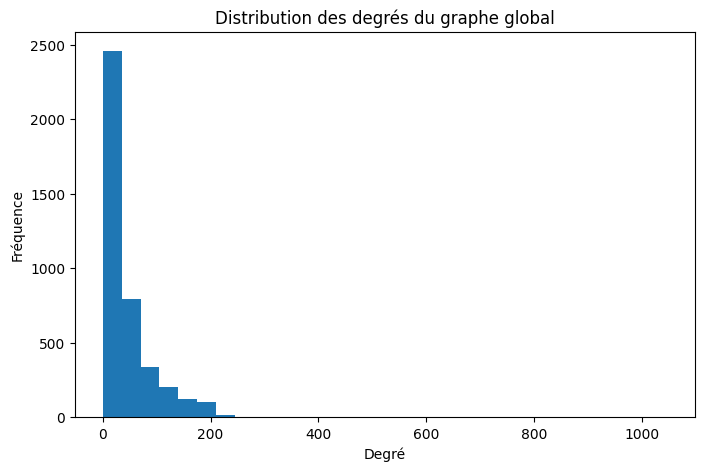

In [ ]:
degrees = [deg for _, deg in G_combined.degree()]

plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=30)
plt.title("Distribution des degrés du graphe global")
plt.xlabel("Degré")
plt.ylabel("Fréquence")
plt.savefig(FIGURES_DIR / "distribution_degres.png", dpi=300, bbox_inches="tight")
plt.show()

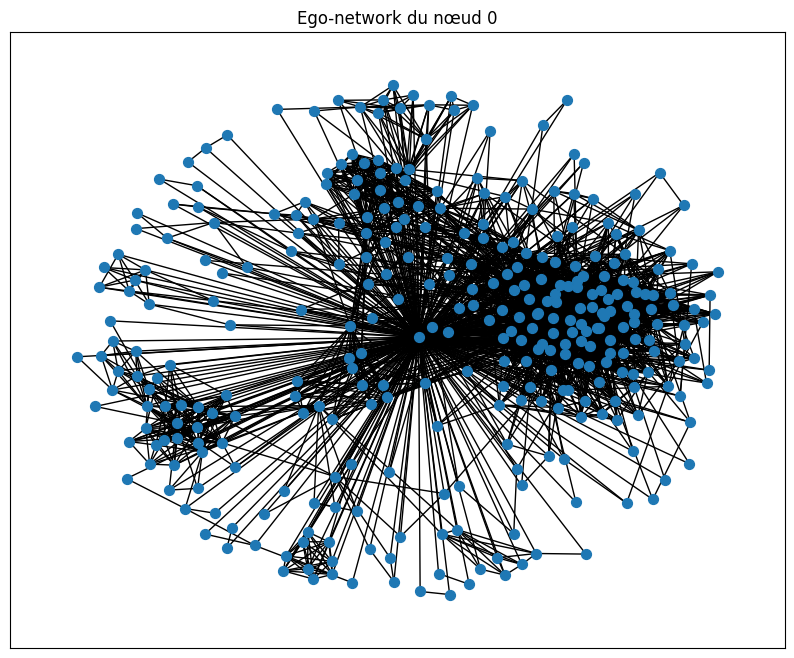

In [ ]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_ego, seed=42)
nx.draw_networkx(G_ego, pos=pos, with_labels=False, node_size=50)
plt.title(f"Ego-network du nœud {ego_id}")
plt.savefig(FIGURES_DIR / f"ego_network_{ego_id}.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:

top_degree_df.to_csv(TABLES_DIR / "top_degree_centrality.csv", index=False)
top_closeness_df.to_csv(TABLES_DIR / "top_closeness_centrality.csv", index=False)
top_betweenness_df.to_csv(TABLES_DIR / "top_betweenness_centrality.csv", index=False)
centralities_df.to_csv(TABLES_DIR / "centralities_summary.csv", index=False)

circles_df.to_csv(TABLES_DIR / f"circles_ego_{ego_id}.csv", index=False)

print("Tableaux sauvegardés.")

Tableaux sauvegardés.


In [ ]:
# communautés Louvain
import community as community_louvain

partition = community_louvain.best_partition(G_combined)
num_communities = len(set(partition.values()))
modularity = community_louvain.modularity(partition, G_combined)

print("Nombre de communautés détectées :", num_communities)
print("Modularité :", round(modularity, 4))

Nombre de communautés détectées : 16
Modularité : 0.8349


In [ ]:
pagerank_centrality = nx.pagerank(G_combined)

top_pagerank = sorted(pagerank_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_pagerank_df = pd.DataFrame(top_pagerank, columns=["node", "pagerank"])

display(top_pagerank_df)

top_pagerank_df.to_csv(TABLES_DIR / "top_pagerank.csv", index=False)

,node,pagerank
0,3437,0.007615
1,107,0.006936
2,1684,0.006367
3,0,0.006290
4,1912,0.003877
5,348,0.002348
6,686,0.002219
7,3980,0.002170
8,414,0.001800
9,698,0.001317


In [ ]:
# récupérer les communautés Louvain dans l’ego-network
import community as community_louvain

partition_ego = community_louvain.best_partition(G_ego)
num_communities_ego = len(set(partition_ego.values()))
modularity_ego = community_louvain.modularity(partition_ego, G_ego)

print("Nombre de communautés Louvain dans l'ego-network :", num_communities_ego)
print("Modularité ego-network :", round(modularity_ego, 4))

Nombre de communautés Louvain dans l'ego-network : 6
Modularité ego-network : 0.4252


In [ ]:

# taille des communautés Louvain

louvain_sizes_df = pd.Series(list(partition_ego.values())).value_counts().sort_values(ascending=False).reset_index()
louvain_sizes_df.columns = ["community", "size"]

display(louvain_sizes_df.head(10))
louvain_sizes_df.to_csv(TABLES_DIR / f"louvain_communities_ego_{ego_id}.csv", index=False)

,community,size
0,4,112
1,0,106
2,5,39
3,1,31
4,3,30
5,2,16


In [ ]:
# comparaison tailles louvain vs circles

comparison_sizes_df = pd.DataFrame({
    "circle_size": sorted(circles_df["size"].tolist(), reverse=True),
})

# On ajoute les tailles Louvain en complétant si nécessaire
louvain_sizes = sorted(louvain_sizes_df["size"].tolist(), reverse=True)
max_len = max(len(comparison_sizes_df), len(louvain_sizes))

comparison_sizes_df = comparison_sizes_df.reindex(range(max_len))
comparison_sizes_df["louvain_size"] = pd.Series(louvain_sizes)

display(comparison_sizes_df.head(15))
comparison_sizes_df.to_csv(TABLES_DIR / f"comparison_circle_louvain_sizes_ego_{ego_id}.csv", index=False)

,circle_size,louvain_size
0,133,112.0
1,32,106.0
2,30,39.0
3,20,31.0
4,20,30.0
5,17,16.0
6,13,NaN
7,10,NaN
8,9,NaN
9,9,NaN


In [ ]:
# comparaison plus intelligente : recouvrement cercle / communauté
# Dictionnaire : communauté -> ensemble de nœuds
community_to_nodes = {}
for node, comm in partition_ego.items():
    community_to_nodes.setdefault(comm, set()).add(node)

comparison_rows = []

for c in circles:
    circle_name = c["circle"]
    circle_members = set(c["members"])
    
    best_community = None
    best_overlap = 0
    best_jaccard = 0.0
    
    for comm, comm_nodes in community_to_nodes.items():
        overlap = len(circle_members & comm_nodes)
        union = len(circle_members | comm_nodes)
        jaccard = overlap / union if union > 0 else 0.0
        
        if jaccard > best_jaccard:
            best_jaccard = jaccard
            best_overlap = overlap
            best_community = comm
    
    comparison_rows.append({
        "circle": circle_name,
        "circle_size": len(circle_members),
        "best_louvain_community": best_community,
        "best_overlap": best_overlap,
        "best_jaccard": best_jaccard
    })

circle_vs_louvain_df = pd.DataFrame(comparison_rows).sort_values("best_jaccard", ascending=False).reset_index(drop=True)
display(circle_vs_louvain_df.head(15))

circle_vs_louvain_df.to_csv(TABLES_DIR / f"circle_vs_louvain_ego_{ego_id}.csv", index=False)

,circle,circle_size,best_louvain_community,best_overlap,best_jaccard
0,circle15,133,0.0,65,0.373563
1,circle6,20,5.0,15,0.340909
2,circle16,32,1.0,15,0.312500
3,circle19,13,5.0,12,0.300000
4,circle11,30,0.0,20,0.172414
5,circle4,17,0.0,15,0.138889
6,circle0,20,4.0,12,0.100000
7,circle20,6,5.0,4,0.097561
8,circle9,10,1.0,3,0.078947
9,circle23,3,5.0,3,0.076923


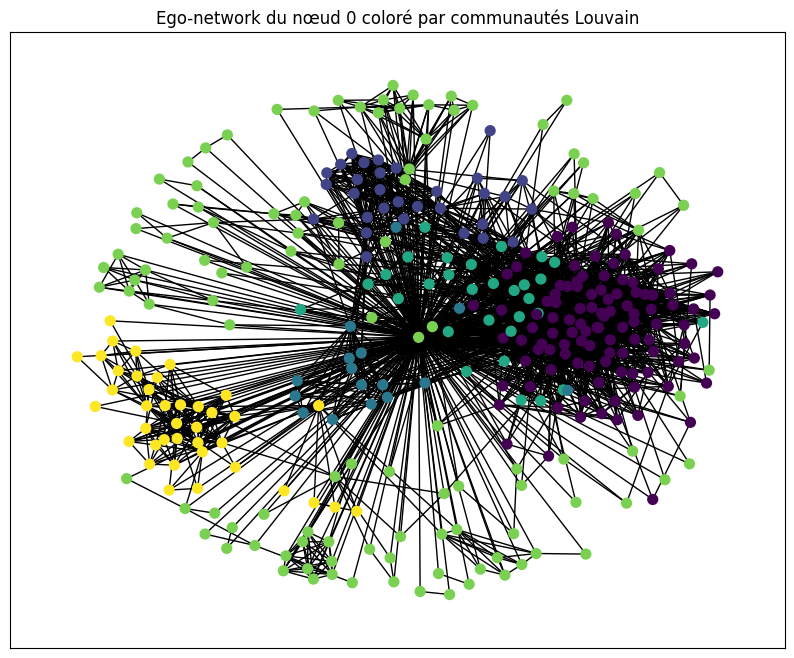

In [ ]:
# node_colors = [partition_ego[node] for node in G_ego.nodes()]
node_colors = [partition_ego[node] for node in G_ego.nodes()]


plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_ego, seed=42)
nx.draw_networkx(
    G_ego,
    pos=pos,
    with_labels=False,
    node_size=50,
    node_color=node_colors
)
plt.title(f"Ego-network du nœud {ego_id} coloré par communautés Louvain")
plt.savefig(FIGURES_DIR / f"ego_network_louvain_{ego_id}.png", dpi=300, bbox_inches="tight")
plt.show()


Fonction de chargement et d’analyse d’un ego-network

In [ ]:
def load_ego_network(ego_id, dataset_dir):
    ego_edges_path = dataset_dir / f"{ego_id}.edges"
    ego_circles_path = dataset_dir / f"{ego_id}.circles"

    ego_edges = pd.read_csv(
        ego_edges_path,
        sep=" ",
        header=None,
        names=["source", "target"]
    )

    G_ego = nx.from_pandas_edgelist(ego_edges, source="source", target="target")

    # Ajouter explicitement l'ego
    G_ego.add_node(int(ego_id))
    for node in set(ego_edges["source"]).union(set(ego_edges["target"])):
        G_ego.add_edge(int(ego_id), node)

    circles = []
    if ego_circles_path.exists():
        with open(ego_circles_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                circle_name = parts[0]
                members = list(map(int, parts[1:]))
                circles.append({"circle": circle_name, "members": members})

    circles_df = pd.DataFrame({
        "circle": [c["circle"] for c in circles],
        "size": [len(c["members"]) for c in circles]
    }) if circles else pd.DataFrame(columns=["circle", "size"])

    partition_ego = community_louvain.best_partition(G_ego)
    num_communities_ego = len(set(partition_ego.values()))
    modularity_ego = community_louvain.modularity(partition_ego, G_ego)

    return {
        "ego_id": ego_id,
        "graph": G_ego,
        "circles": circles,
        "circles_df": circles_df,
        "partition": partition_ego,
        "num_nodes": G_ego.number_of_nodes(),
        "num_edges": G_ego.number_of_edges(),
        "num_circles": len(circles),
        "num_communities": num_communities_ego,
        "modularity": modularity_ego
    }

In [ ]:
# Test sur un deuxième ego-network

ego_107_results = load_ego_network("107", DATASET_DIR)

print("Ego :", ego_107_results["ego_id"])
print("Nombre de nœuds :", ego_107_results["num_nodes"])
print("Nombre d’arêtes :", ego_107_results["num_edges"])
print("Nombre de cercles :", ego_107_results["num_circles"])
print("Nombre de communautés Louvain :", ego_107_results["num_communities"])
print("Modularité :", round(ego_107_results["modularity"], 4))

ego_107_results["circles_df"].sort_values("size", ascending=False).head(10)

Ego : 107
Nombre de nœuds : 1035
Nombre d’arêtes : 27783
Nombre de cercles : 9
Nombre de communautés Louvain : 6
Modularité : 0.5274


,circle,size
6,circle6,308
3,circle3,39
5,circle5,37
8,circle8,35
7,circle7,27
2,circle2,19
1,circle1,16
0,circle0,10
4,circle4,10


In [ ]:
# Comparer ego 0 et ego 107

comparison_egos_df = pd.DataFrame([
    {
        "ego_id": ego_id,
        "num_nodes": G_ego.number_of_nodes(),
        "num_edges": G_ego.number_of_edges(),
        "num_circles": len(circles),
        "num_communities": num_communities_ego,
        "modularity": modularity_ego
    },
    {
        "ego_id": ego_107_results["ego_id"],
        "num_nodes": ego_107_results["num_nodes"],
        "num_edges": ego_107_results["num_edges"],
        "num_circles": ego_107_results["num_circles"],
        "num_communities": ego_107_results["num_communities"],
        "modularity": ego_107_results["modularity"]
    }
])

display(comparison_egos_df)
comparison_egos_df.to_csv(TABLES_DIR / "comparison_ego_0_vs_107.csv", index=False)

,ego_id,num_nodes,num_edges,num_circles,num_communities,modularity
0,0,334,2852,24,6,0.425239
1,107,1035,27783,9,6,0.527369


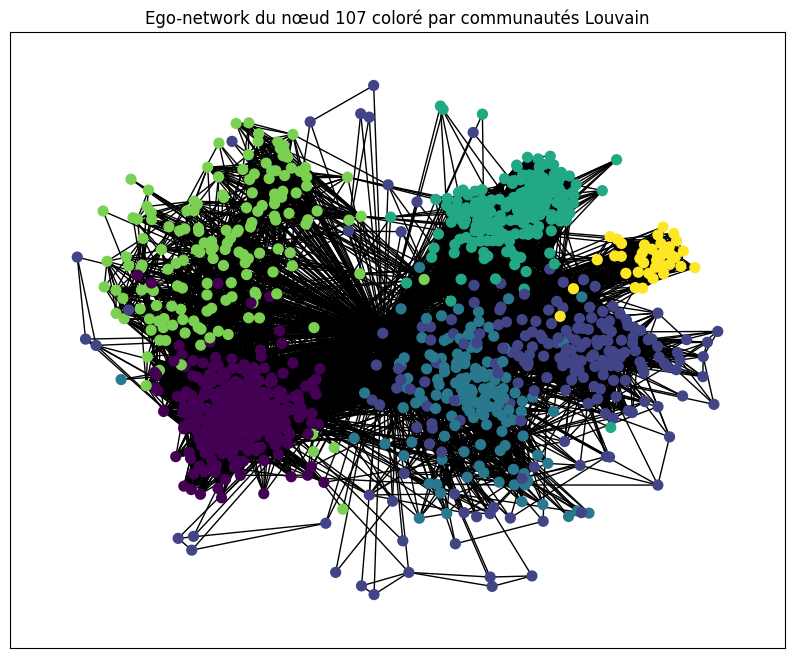

In [ ]:
# visualisations
G_ego_107 = ego_107_results["graph"]
partition_ego_107 = ego_107_results["partition"]

node_colors_107 = [partition_ego_107[node] for node in G_ego_107.nodes()]

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_ego_107, seed=42)
nx.draw_networkx(
    G_ego_107,
    pos=pos,
    with_labels=False,
    node_size=50,
    node_color=node_colors_107
)
plt.title("Ego-network du nœud 107 coloré par communautés Louvain")
plt.savefig(FIGURES_DIR / "ego_network_louvain_107.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
def summarize_ego_results(ego_results):
    print(f"Ego : {ego_results['ego_id']}")
    print(f"Nombre de nœuds : {ego_results['num_nodes']}")
    print(f"Nombre d’arêtes : {ego_results['num_edges']}")
    print(f"Nombre de cercles : {ego_results['num_circles']}")
    print(f"Nombre de communautés Louvain : {ego_results['num_communities']}")
    print(f"Modularité : {round(ego_results['modularity'], 4)}")
    
    if not ego_results["circles_df"].empty:
        display(ego_results["circles_df"].sort_values("size", ascending=False).head(10))


summarize_ego_results(ego_107_results)

ego_0_results = load_ego_network("0", DATASET_DIR)
summarize_ego_results(ego_0_results)

Ego : 107
Nombre de nœuds : 1035
Nombre d’arêtes : 27783
Nombre de cercles : 9
Nombre de communautés Louvain : 6
Modularité : 0.5274


,circle,size
6,circle6,308
3,circle3,39
5,circle5,37
8,circle8,35
7,circle7,27
2,circle2,19
1,circle1,16
0,circle0,10
4,circle4,10


Ego : 0
Nombre de nœuds : 334
Nombre d’arêtes : 2852
Nombre de cercles : 24
Nombre de communautés Louvain : 9
Modularité : 0.4284


,circle,size
15,circle15,133
16,circle16,32
11,circle11,30
0,circle0,20
6,circle6,20
4,circle4,17
19,circle19,13
9,circle9,10
2,circle2,9
17,circle17,9


In [ ]:
final_summary_df = pd.DataFrame([
    {
        "analysis_level": "global_graph",
        "id": "combined",
        "num_nodes": num_nodes,
        "num_edges": num_edges,
        "num_communities": num_communities,
        "modularity": modularity
    },
    {
        "analysis_level": "ego_network",
        "id": ego_0_results["ego_id"],
        "num_nodes": ego_0_results["num_nodes"],
        "num_edges": ego_0_results["num_edges"],
        "num_communities": ego_0_results["num_communities"],
        "modularity": ego_0_results["modularity"]
    },
    {
        "analysis_level": "ego_network",
        "id": ego_107_results["ego_id"],
        "num_nodes": ego_107_results["num_nodes"],
        "num_edges": ego_107_results["num_edges"],
        "num_communities": ego_107_results["num_communities"],
        "modularity": ego_107_results["modularity"]
    }
])

display(final_summary_df)
final_summary_df.to_csv(TABLES_DIR / "final_summary.csv", index=False)

,analysis_level,id,num_nodes,num_edges,num_communities,modularity
0,global_graph,combined,4039,88234,16,0.834943
1,ego_network,0,334,2852,9,0.428414
2,ego_network,107,1035,27783,6,0.527369


In [ ]:
print("Résumé final de l'analyse")
print(f"Graphe global : {num_nodes} nœuds, {num_edges} arêtes, {num_communities} communautés, modularité = {modularity:.4f}")
print(f"Ego 0 : {ego_0_results['num_nodes']} nœuds, {ego_0_results['num_edges']} arêtes, {ego_0_results['num_circles']} cercles, {ego_0_results['num_communities']} communautés, modularité = {ego_0_results['modularity']:.4f}")
print(f"Ego 107 : {ego_107_results['num_nodes']} nœuds, {ego_107_results['num_edges']} arêtes, {ego_107_results['num_circles']} cercles, {ego_107_results['num_communities']} communautés, modularité = {ego_107_results['modularity']:.4f}")
print(f"Nœud le plus central (degree) : {top_degree[0][0]}")
print(f"Nœud le plus influent selon PageRank : {top_pagerank[0][0]}")

Résumé final de l'analyse
Graphe global : 4039 nœuds, 88234 arêtes, 16 communautés, modularité = 0.8349
Ego 0 : 334 nœuds, 2852 arêtes, 24 cercles, 9 communautés, modularité = 0.4284
Ego 107 : 1035 nœuds, 27783 arêtes, 9 cercles, 6 communautés, modularité = 0.5274
Nœud le plus central (degree) : 107
Nœud le plus influent selon PageRank : 3437
